In [1]:
import numpy as np
import pandas as pd
from scipy import optimize, special
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
data = pd.read_csv("china_gdp.csv")
data

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


In [3]:
def model(x, B1, B2, B3):
    return B3 * special.expit(B1 * (x - B2))

In [4]:
popt, pcov = optimize.curve_fit(model, data["Year"], data["Value"], p0=[0.1, 2000, 1e13])
popt, np.sqrt(np.diag(pcov))

(array([1.75242130e-01, 2.02137005e+03, 4.99848964e+13]),
 array([9.74999313e-03, 3.47709923e+00, 2.16893738e+13]))

In [5]:
xlin = np.linspace(1960, 2050, 200)
ylin = model(xlin, *popt)

In [6]:
xr = 1970
yr = model(xr, *popt)

In [7]:
yhat = model(data["Year"], *popt)

In [8]:
r2 = metrics.r2_score(data["Value"], yhat)
r2

0.9937888221869231

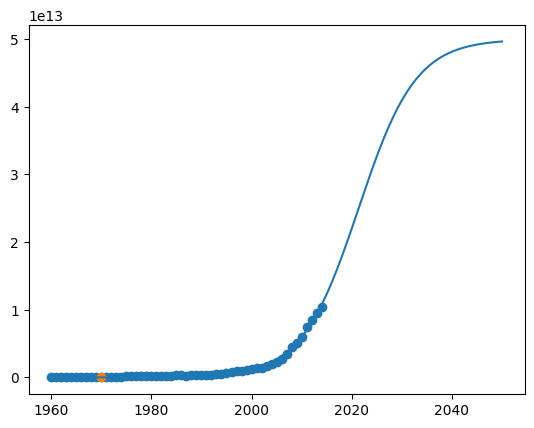

In [9]:
fig, axe = plt.subplots()
axe.scatter(data["Year"], data["Value"])
axe.scatter(xr, yr)
axe.plot(xlin, ylin)

In [10]:
x = data["Year"].values
y = data["Value"].values

In [11]:
u = (x - x.min()) / (x.max() - x.min())
v = (y - y.min()) / (y.max() - y.min())

In [12]:
popt1, pcov1 = optimize.curve_fit(model, u, v)
popt1, np.sqrt(np.diag(pcov1))

(array([10.02621255,  1.09246088,  3.65959461]),
 array([0.50701378, 0.04251404, 1.03346957]))

In [13]:
x0 = 1970
u0 = (x0 - x.min()) / (x.max() - x.min())
v0 = model(u0, *popt1)
y0 = v0 * (y.max() - y.min()) + y.min()

In [14]:
y0

np.float64(50911750065.98366)